In [1]:
%matplotlib ipympl
from analysis.loaders import *
from config import *
from analysis.readout_dataset import *
from analysis.plotting import plot_single_iq_data
from analysis.plotting import plot_map
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider


In [2]:
qubit_name = 'q16'

data_sets = {
    'With TWPA': ReadoutDataset(qubit_name, with_twpa=True, npz=True),
    'Without TWPA': ReadoutDataset(qubit_name, with_twpa=False, npz=True)
}

Output()

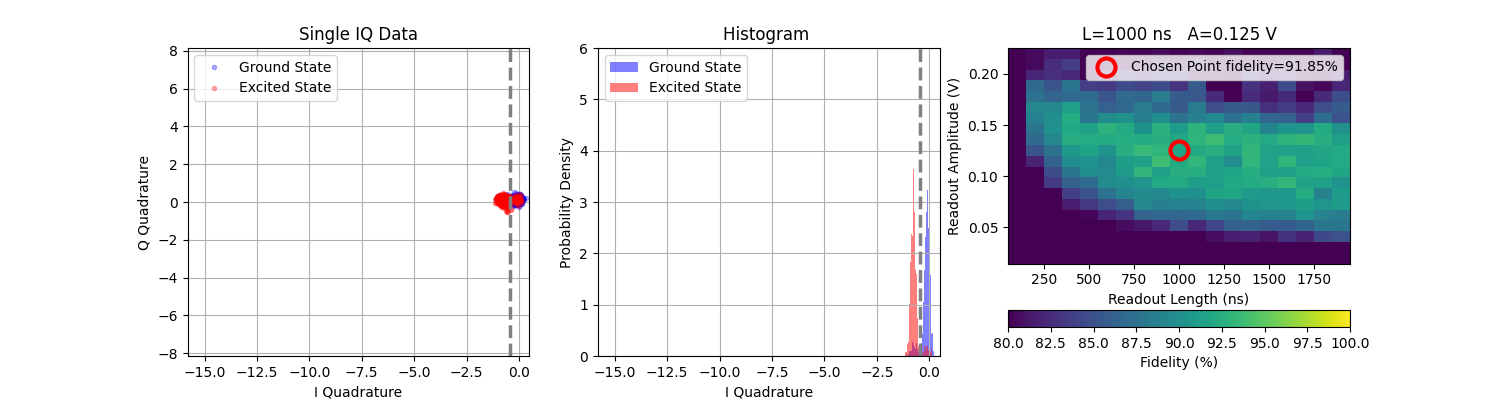

In [3]:

from matplotlib.pyplot import plot


def visulize():

    # ---- TWPA SWITCH ----
    twpa_switch = widgets.ToggleButtons(
        options=['Without TWPA', 'With TWPA'],
        value='Without TWPA',
        description='TWPA:',
        button_style=''
    )

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    data_set = data_sets['Without TWPA']
    
    c = data_set.plot_fidelity_map(
        ax=axs[2], point=(100e-9, 0.01), vmin=80, vmax=100)

    cbar = fig.colorbar(
        c, ax=axs[2], orientation='horizontal', label='Fidelity (%)'
    )

    fig.canvas.draw_idle()

    def ploti(l, a, scailing, twpa_option):
        # ---- INTERNAL PLOT FUNCTION ----
        for ax in axs:
            ax.clear()

        # pick dataset dynamically
        data_set = data_sets[twpa_option]

        # build figure
        base_xlim = 0.5

        data_set.plot_single_iq_data(
            length=l,
            amplitude=a,
            axs=axs[:2],
            plot=True,
            xlim=(-scailing-base_xlim, base_xlim),
            ylim=(-scailing/2-base_xlim, scailing/2+base_xlim)
        )

        c = data_set.plot_fidelity_map(
            ax=axs[2], point=(l, a), vmin=80, vmax=100)

        axs[0].set_title(f"Single IQ Data")
        axs[1].set_title(f"Histogram ")
        axs[2].set_title(f"L={l/1e-9:.0f} ns   A={a:.3f} V")

    # ---- INITIAL DATASET ----
    data_set = data_sets['Without TWPA']
    l_vals = data_set.lengths
    a_vals = data_set.amplitudes
    s_vals = np.linspace(0.01, 30, 50)

    # ---- SLIDERS ----
    l_slider = FloatSlider(
        value=l_vals[len(l_vals)//2],
        min=l_vals.min(),
        max=l_vals.max(),
        step=(l_vals[1] - l_vals[0]),
        description='Length (s)',
        readout_format='.2e',
        continuous_update=False
    )

    a_slider = FloatSlider(
        value=a_vals[len(a_vals)//2],
        min=a_vals.min(),
        max=a_vals.max(),
        step=(a_vals[1] - a_vals[0]),
        description='Amplitude',
        readout_format='.3f',
        continuous_update=False
    )

    s_slider = FloatSlider(
        value=s_vals[len(s_vals)//2],
        min=s_vals.min(),
        max=s_vals.max(),
        step=(s_vals[1] - s_vals[0]),
        description='Scaling',
        readout_format='.3f',
        continuous_update=False
    )

    # ---- UI LAYOUT ----
    ui = widgets.VBox([twpa_switch, l_slider, a_slider, s_slider])

    out = widgets.interactive_output(
        ploti,
        {
            'l': l_slider,
            'a': a_slider,
            'scailing': s_slider,
            'twpa_option': twpa_switch
        }
    )

    display(ui, out)


visulize()